# 1. Import Libraries

In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

# 2. Load Dataset

In [50]:
df = pd.read_csv("student_performance.csv")

# 3. Data Exploration

In [51]:
print(df.head())


  Student_ID         Name  Age Program  Python  Mathematics  Statistics  \
0       S001     Ali Khan   20      AI      85           78          92   
1       S002   Sara Ahmed   21      AI      72           75          70   
2       S003   Ahmed Raza   22      SE      90           88          91   
3       S004  Fatima Noor   20      DS      65           70          68   
4       S005    Usman Ali   21      AI      78           82          80   

   Machine_Learning  Attendance  
0                88          95  
1                80          90  
2                93          96  
3                72          85  
4                76          88  


In [52]:
print(df.shape)

(20, 9)


In [53]:
print(df.columns)

Index(['Student_ID', 'Name', 'Age', 'Program', 'Python', 'Mathematics',
       'Statistics', 'Machine_Learning', 'Attendance'],
      dtype='object')


In [54]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Student_ID        20 non-null     object
 1   Name              20 non-null     object
 2   Age               20 non-null     int64 
 3   Program           20 non-null     object
 4   Python            20 non-null     int64 
 5   Mathematics       20 non-null     int64 
 6   Statistics        20 non-null     int64 
 7   Machine_Learning  20 non-null     int64 
 8   Attendance        20 non-null     int64 
dtypes: int64(6), object(3)
memory usage: 1.5+ KB
None


In [55]:
print(df.describe())

             Age     Python  Mathematics  Statistics  Machine_Learning  \
count  20.000000  20.000000    20.000000   20.000000         20.000000   
mean   21.100000  78.900000    79.500000   80.600000         82.600000   
std     1.020836  11.702002    10.226385   11.366618         10.575045   
min    20.000000  55.000000    60.000000   58.000000         62.000000   
25%    20.000000  71.250000    71.750000   73.000000         75.000000   
50%    21.000000  79.500000    80.000000   79.500000         82.500000   
75%    22.000000  88.250000    88.250000   90.250000         90.250000   
max    23.000000  97.000000    95.000000   98.000000         99.000000   

       Attendance  
count   20.000000  
mean    89.600000  
std      7.170113  
min     75.000000  
25%     84.750000  
50%     90.500000  
75%     95.250000  
max    100.000000  


In [56]:
print(df.isnull().sum())

Student_ID          0
Name                0
Age                 0
Program             0
Python              0
Mathematics         0
Statistics          0
Machine_Learning    0
Attendance          0
dtype: int64


In [57]:
print(df.dtypes)

Student_ID          object
Name                object
Age                  int64
Program             object
Python               int64
Mathematics          int64
Statistics           int64
Machine_Learning     int64
Attendance           int64
dtype: object


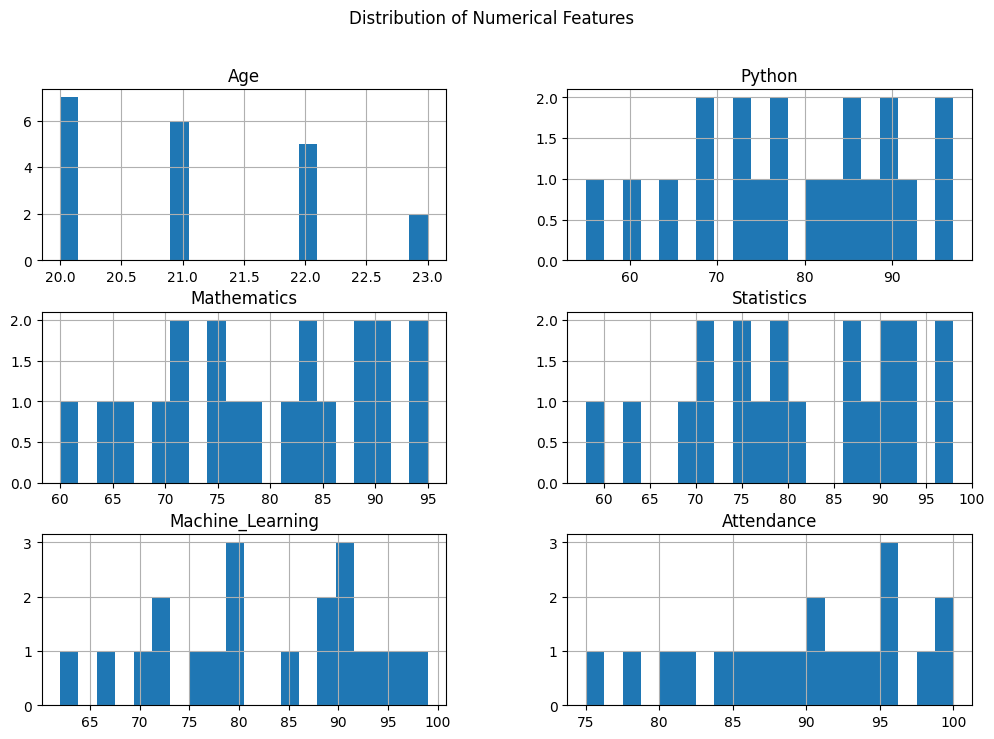

In [58]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

df[numerical_columns].hist(figsize=(12,8), bins=20)

plt.suptitle("Distribution of Numerical Features")
plt.show()

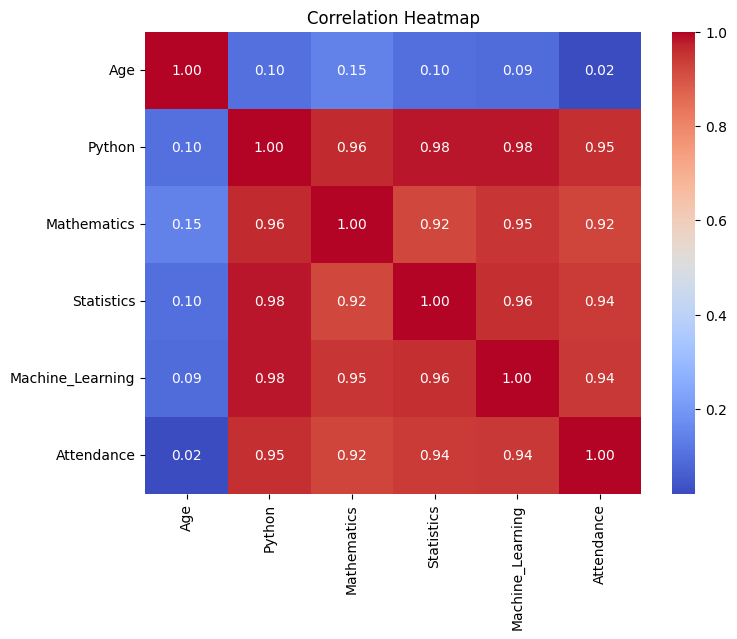

In [59]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [60]:
df["Average_Score"] = (df["Python"] +df["Mathematics"] +df["Statistics"] + df["Machine_Learning"])/4

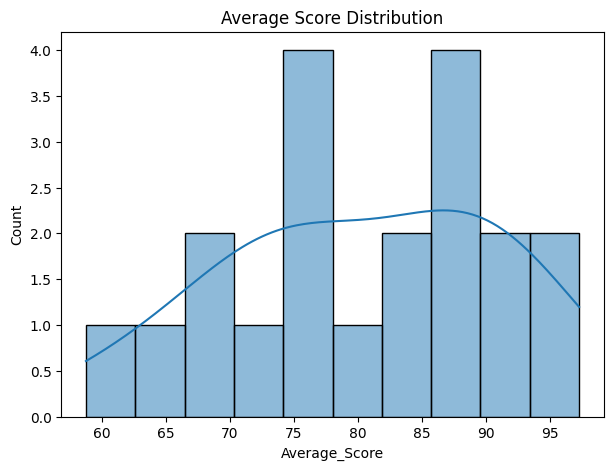

In [61]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["Average_Score"],
    bins=10,
    kde=True
)

plt.title("Average Score Distribution")

plt.show()

# 4. One Hot Encoding  Encoding by Pandas

In [62]:
df = pd.get_dummies(df, columns=["Program"], dtype=int)

In [63]:
print(df.head(2))

  Student_ID        Name  Age  Python  Mathematics  Statistics  \
0       S001    Ali Khan   20      85           78          92   
1       S002  Sara Ahmed   21      72           75          70   

   Machine_Learning  Attendance  Average_Score  Program_AI  Program_DS  \
0                88          95          85.75           1           0   
1                80          90          74.25           1           0   

   Program_SE  
0           0  
1           0  


In [64]:
X = df.drop(columns=["Student_ID", "Name", "Average_Score"])
y = df["Average_Score"]

In [65]:
print(X.head(2))

   Age  Python  Mathematics  Statistics  Machine_Learning  Attendance  \
0   20      85           78          92                88          95   
1   21      72           75          70                80          90   

   Program_AI  Program_DS  Program_SE  
0           1           0           0  
1           1           0           0  


In [66]:
print(y.head(2))

0    85.75
1    74.25
Name: Average_Score, dtype: float64


# 5. Train Test Split

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [68]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (16, 9)
Testing Features Shape: (4, 9)
Training Labels Shape: (16,)
Testing Labels Shape: (4,)


# 6. Scaling

In [69]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [70]:
print(X_train[:5])

[[ 1.78017249 -0.37081147 -0.12009212 -0.37566552 -0.18681819 -0.89399858
  -0.77459667 -0.67419986  1.4832397 ]
 [ 0.83074716  1.57733239  1.59912135  1.59657848  1.54878304  1.56223995
  -0.77459667 -0.67419986  1.4832397 ]
 [-0.11867817  1.31167641  1.19460053  1.31482934  1.35593846  1.41775533
  -0.77459667 -0.67419986  1.4832397 ]
 [-1.06810349 -1.07922742 -0.82800354 -1.03308019 -0.86177422 -0.46054472
  -0.77459667  1.4832397  -0.67419986]
 [-0.11867817 -0.81357144 -1.23252436 -0.84524743 -0.86177422 -1.18296782
  -0.77459667  1.4832397  -0.67419986]]


# 7. Model Training

In [71]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


# 8. Prediction

In [72]:
y_pred = model.predict(X_test)
print("Predicted Scores:")
print(y_pred)

Predicted Scores:
[85.75 97.25 89.5  74.25]


# 9. Evaluation

In [73]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("-" * 30)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation Metrics
------------------------------
Mean Absolute Error (MAE): 0.00
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.00
R² Score: 1.0000


In [74]:
comparison = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": y_pred
})

comparison["Difference"] = comparison["Actual Score"] - comparison["Predicted Score"]

print(comparison)

   Actual Score  Predicted Score  Difference
0         85.75            85.75         0.0
1         97.25            97.25         0.0
2         89.50            89.50         0.0
3         74.25            74.25         0.0


# 10. Visual Representation of Best fit line

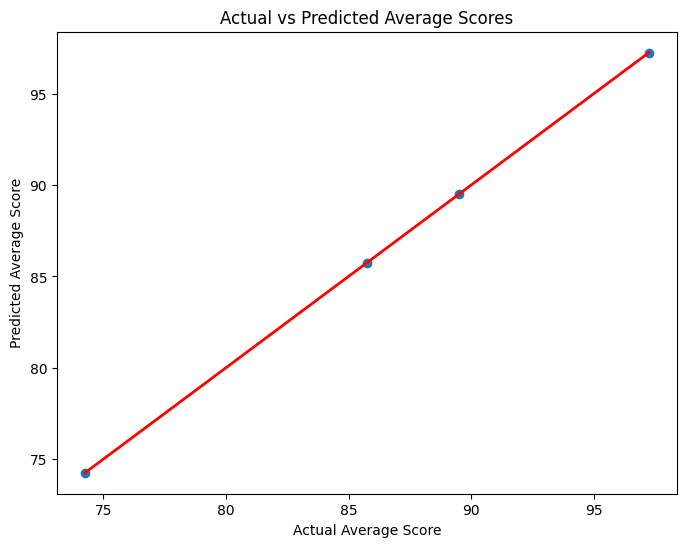

In [75]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted Average Scores")
plt.xlabel("Actual Average Score")
plt.ylabel("Predicted Average Score")

plt.show()